## **Edward Moswane Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [1]:
# Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Data Collection and Loading

In [2]:
# Load the Boston Housing dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Converting to DF
X_data = boston.data
y_data = boston.target

# converting to numeric
X_data = X_data.apply(pd.to_numeric)
y_data = pd.to_numeric(y_data)

df = X_data.copy()
df["MEDV"] = y_data

# show shape of dataset
print("Dataset shape:", df.shape)

Dataset shape: (506, 14)


##  Quick Check of Data

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


 ## Inspect data types and statistical properties

In [25]:
# Checking data types and information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [26]:
# shows statistics of the dataset
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## EDA and Data Preprocessing

In [7]:
#Checking missing values
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


## Visualize the Data

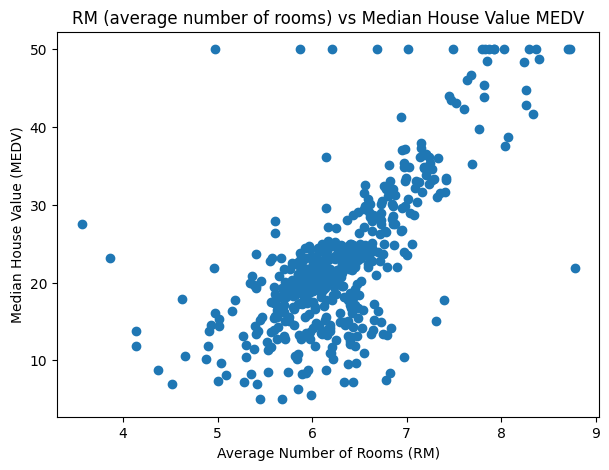

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(df["RM"], df["MEDV"])
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("RM (average number of rooms) vs Median House Value MEDV")
plt.show()

## Function for Multiple Scatter Plots

In [11]:
# Function to create scatter plots for multiple features

def plot_features_vs_target(data, features, target):
    for feature in features:
        plt.figure(figsize=(6, 4))
        plt.scatter(data[feature], data[target])
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.tight_layout()
        plt.show()

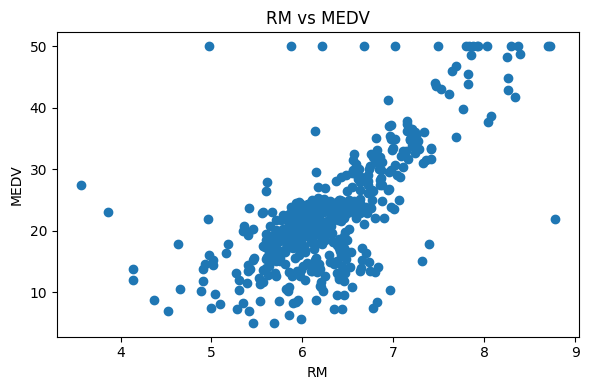

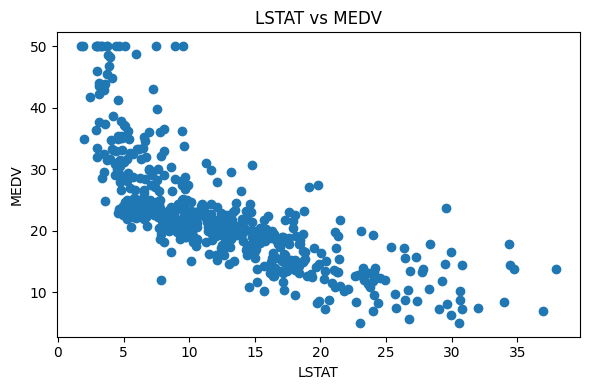

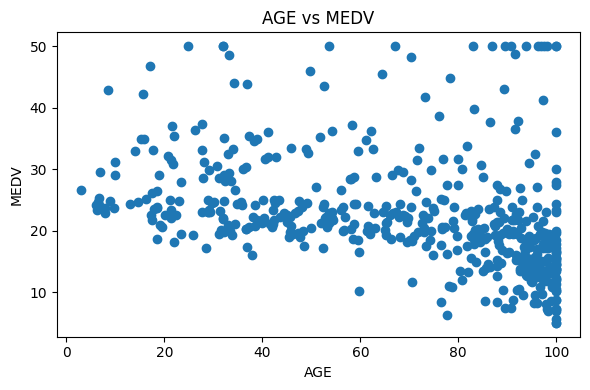

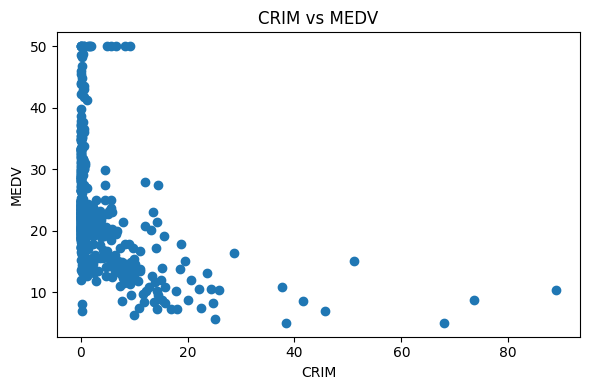

In [12]:
# visualizing the relationships between multiple features and the target variabl

features_to_plot = ["RM", "LSTAT", "AGE", "CRIM"]

plot_features_vs_target(df, features_to_plot, "MEDV")

## ML Model Training

In [13]:
# Define features (X) and target (y)
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Spliting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 404
Testing samples: 102


In [14]:
# Defining the Random Forest regression model

model = RandomForestRegressor(n_estimators=100,random_state=42)

## Train the model on the training data.

In [15]:
model.fit(X_train, y_train)

print("Finally Model training completed successfully!!!.")

Finally Model training completed successfully!!!.


## Model Evaluation

In [20]:
#Perform parameter tuning on the model
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),param_grid,cv=5,scoring="neg_mean_squared_error",n_jobs=-1)
grid_search.fit(X_train, y_train)

# Show the best parameters
print("The Best Parameters are:", grid_search.best_params_)

The Best Parameters are: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [21]:
# Use the best model found during tuning
best_model = grid_search.best_estimator_

print(best_model)

RandomForestRegressor(random_state=42)


## Make predictions

In [22]:
# Model Predictions on the test data
y_pred = best_model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

RMSE: 2.8110
R-squared: 0.8923


In [24]:
# Predict house prices from a new set of feature inputs using hypothetical or randomly generated values
new_data = pd.DataFrame({
    "CRIM": [0.2],
    "ZN": [12.5],
    "INDUS": [7.07],
    "CHAS": [0],
    "NOX": [0.5],
    "RM": [6.5],
    "AGE": [68],
    "DIS": [4.0],
    "RAD": [2],
    "TAX": [250],
    "PTRATIO": [17],
    "B": [400],
    "LSTAT": [12]})

# Predict the house price
predicted_price = best_model.predict(new_data)

print(f"Predicted Median House Value: {predicted_price[0]:.4f}")
print(f"Predicted House Value: ${predicted_price[0] * 1000:,.2f}")

Predicted Median House Value: 22.1890
Predicted House Value: $22,189.00


**In conclusion**, the Random Forest regression model performed well, achieving an R² of 0.8923 and an RMSE of 2.8110. This shows that the model can produce accurate house price predictions.

**Colab Link**

https://colab.research.google.com/drive/17xFenmIjEDyAT9PmYsVE7R3Xek6gHC1N?usp=sharing

GitHub